In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from scipy.stats import ttest_rel

MOTIF_DESCRIPTIONS = {
    0: "torso rotation",
    1: "stretch (one body part)",
    2: "depart",
    3: "arm/hand movement",
    4: "static/fidget",
    5: "standstill",
    6: "wander and scan",
    7: "turn from/to",
    8: "examine/ with objects",
    9: "approach (aimed) or inspect"
}

def plot_motif_comparison(lb, ub, a, b):
    # Load the CSV file
    csv_file = "average_pairwise_distances.csv"
    df = pd.read_csv(csv_file, index_col=0)
    df.index.name = "Keypoint Pair"

    # Function to extract data for given pairs
    def extract_data(pairs, motif):
        return np.array([df.loc[pair, f"Motif {motif}"] for pair in pairs])

    # Extract data for Lower Body
    lower_a_data = extract_data(lb, a)
    lower_b_data = extract_data(lb, b)

    # Extract data for Upper Body
    upper_a_data = extract_data(ub, a)
    upper_b_data = extract_data(ub, b)

    # Calculate standard deviation for error bars
    lower_a_std = np.std(lower_a_data)
    lower_b_std = np.std(lower_b_data)
    upper_a_std = np.std(upper_a_data)
    upper_b_std = np.std(upper_b_data)

    # Perform paired t-test for statistical significance
    lower_p_value = ttest_rel(lower_a_data, lower_b_data).pvalue
    upper_p_value = ttest_rel(upper_a_data, upper_b_data).pvalue
    colors = ['#1F77B4', '#FF7F0E']
    # Plotting Lower Body Rotation]
    fig, axes = plt.subplots(1, 2, figsize=(14, 6))
    width = 0.35

    import seaborn as sns


    x_lower = np.arange(len(lb))
    axes[0].bar(x_lower - width / 2, lower_a_data, width, label=f"Motif {a}", yerr=lower_a_std, capsize=5, color=colors[0])
    axes[0].bar(x_lower + width / 2, lower_b_data, width, label=f"Motif {b}", yerr=lower_b_std, capsize=5, color=colors[1])
    axes[0].set_xticks(x_lower)
    axes[0].set_xticklabels(lb, rotation=45, ha="right")
    axes[0].set_ylabel("Average Distance")
    axes[0].set_title(f"Lower Body Rotation: {MOTIF_DESCRIPTIONS[a]} vs {MOTIF_DESCRIPTIONS[b]}\n(p-value: {lower_p_value:.4f})")
    axes[0].legend()

    # Plotting Upper Body/Head Rotation
    x_upper = np.arange(len(ub))
    axes[1].bar(x_upper - width / 2, upper_a_data, width, label=f"Motif {a}", yerr=upper_a_std, capsize=5, color=colors[0])
    axes[1].bar(x_upper + width / 2, upper_b_data, width, label=f"Motif {b}", yerr=upper_b_std, capsize=5, color=colors[1])
    axes[1].set_xticks(x_upper)
    axes[1].set_xticklabels(ub, rotation=45, ha="right")
    axes[1].set_ylabel("Average Distance")
    axes[1].set_title(f"Upper Body/Head Rotation: {MOTIF_DESCRIPTIONS[a]} vs {MOTIF_DESCRIPTIONS[b]}\n(p-value: {upper_p_value:.4f})")
    axes[1].legend()

    # Layout adjustment
    plt.tight_layout()
    plt.show()

    # Output statistical results
    print(f"Lower Body Rotation p-value: {lower_p_value:.4f}")
    print(f"Upper Body/Head Rotation p-value: {upper_p_value:.4f}")


# 1. Turning vs. Departing
## Motif 2 (Depart from Previous Action) vs. Motif 7 (Turn From/To)
### Keypoint Pairs to Compare:

#### Lower Body Rotation:
- center_hip - l-hip
- center_hip - r-hip
- l-hip - r-hip
#### Upper Body/Head Rotation:
- center_neck - l_sho
- center_neck - r_sho
- center_neck - l_eye
- center_neck - r_eye

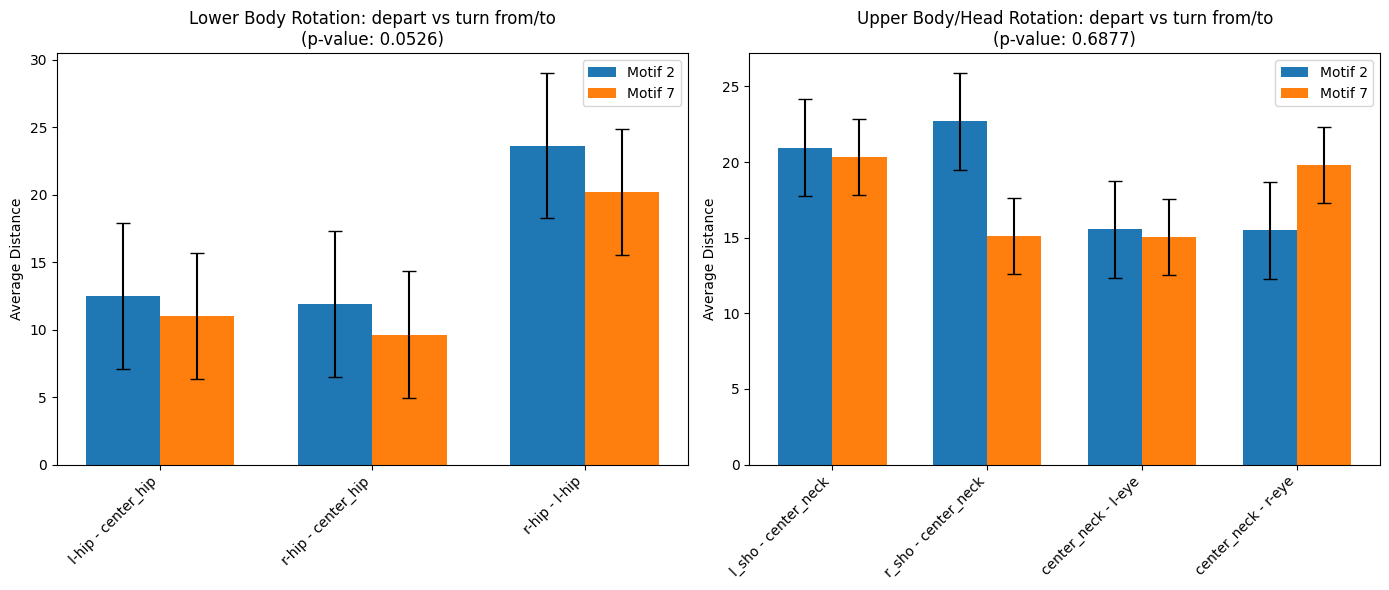

Lower Body Rotation p-value: 0.0526
Upper Body/Head Rotation p-value: 0.6877


In [23]:
# Lower Body Rotation keypoint pairs (correct order)
lower_body_pairs = [
    "l-hip - center_hip",
    "r-hip - center_hip",
    "r-hip - l-hip"
]

# Upper Body/Head Rotation keypoint pairs (correct order)
upper_body_pairs = [
    "l_sho - center_neck",
    "r_sho - center_neck",
    "center_neck - l-eye",
    "center_neck - r-eye"
]

plot_motif_comparison(lower_body_pairs, upper_body_pairs, 2, 7)

# 2. Arm Movement vs. Fidgeting
## Motif 3 (Arm and Hand Movement) vs. Motif 4 (Static or Fidget)
### Keypoint Pairs to Compare:

#### Focused Arm/Hand Movements:
- l-hand - l-elb
- r-hand - r-elb
- l-elb - l-sho
- r-elb - r-sho
#### Head/Eye Coordination:
- center_neck - l_eye
- center_neck - r_eye

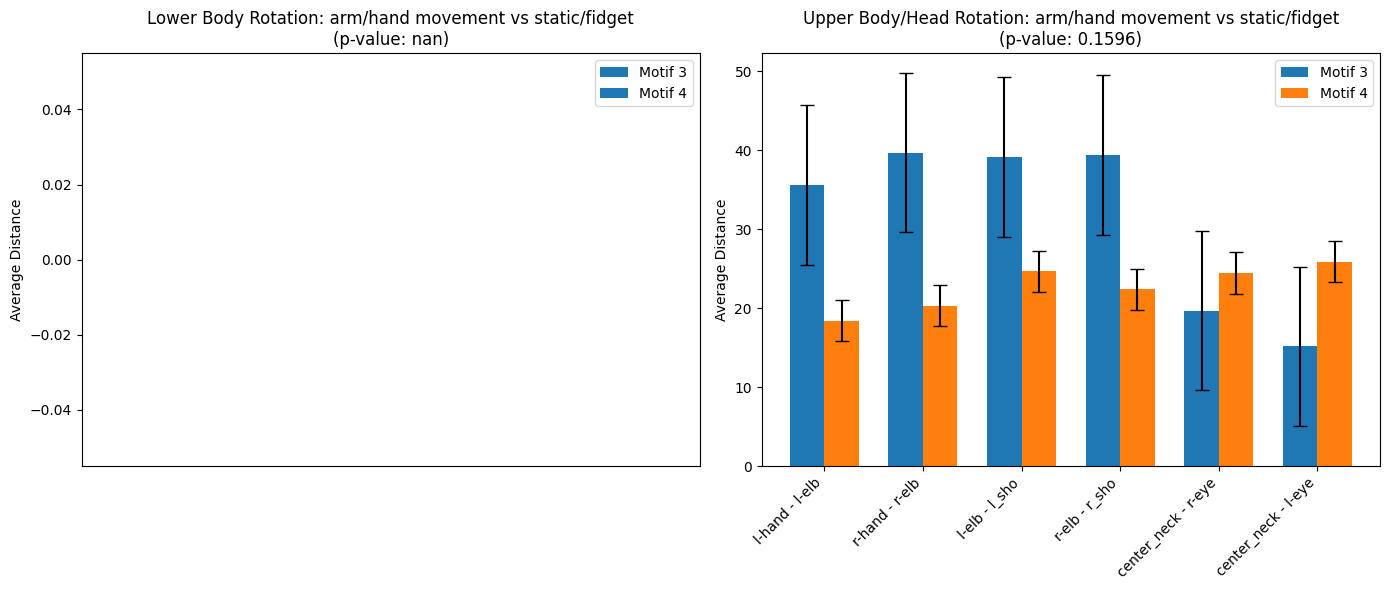

Lower Body Rotation p-value: nan
Upper Body/Head Rotation p-value: 0.1596


In [24]:
# Lower Body Pairs
lower_body_pairs = [
    
]

# Upper Body Pairs
upper_body_pairs = [
    "l-hand - l-elb",
    "r-hand - r-elb",
    "l-elb - l_sho",
    "r-elb - r_sho",
    "center_neck - r-eye",
    "center_neck - l-eye"
]

plot_motif_comparison(lower_body_pairs, upper_body_pairs, 3, 4)

# 3. Stretching vs. Fidgeting
## Motif 1 (Stretch One Body Part) vs. Motif 4 (Static or Fidget)
### Keypoint Pairs to Compare:

#### Limb Extension:
- l-hand - l-sho
- r-hand - r-sho
- l-feet - l-hip
- r-feet - r-hip
#### Head Stability:
- center_neck - center_hip



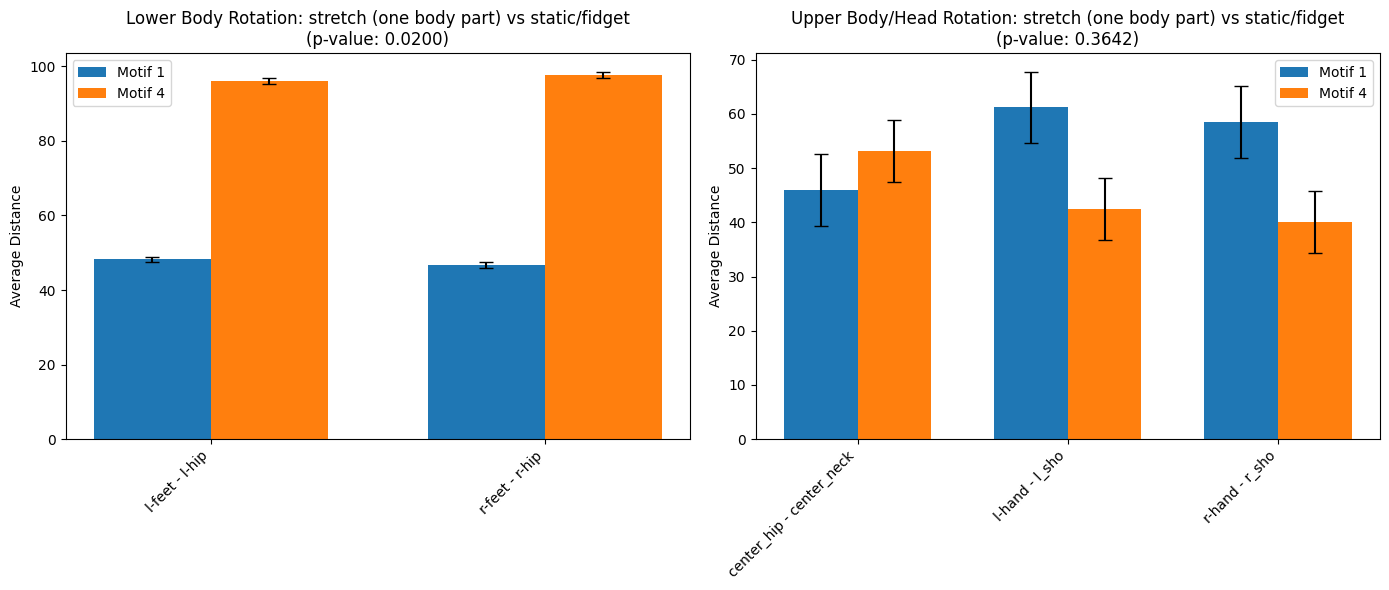

Lower Body Rotation p-value: 0.0200
Upper Body/Head Rotation p-value: 0.3642


In [25]:
# Limb Extension Pairs
limb_extension_pairs = [
    
    "l-feet - l-hip",
    "r-feet - r-hip"
]

# Head Stability Pair
head_stability_pair = [
    "center_hip - center_neck",
    "l-hand - l_sho",
    "r-hand - r_sho",
]

plot_motif_comparison(limb_extension_pairs, head_stability_pair, 1, 4)


# 4. Arm Movement vs. Object Interaction
## Motif 3 (Arm and Hand Movement) vs. Motif 8 (Examine/Interact with Objects)
#### Keypoint Pairs to Compare:

#### Arm Mechanics:
- l-hand - l-elb
- r-hand - r-elb
#### Head/Gaze Coordination:
- center_neck - l_eye
- center_neck - r_eye
- center_neck - l-hand
- center_neck - r-hand



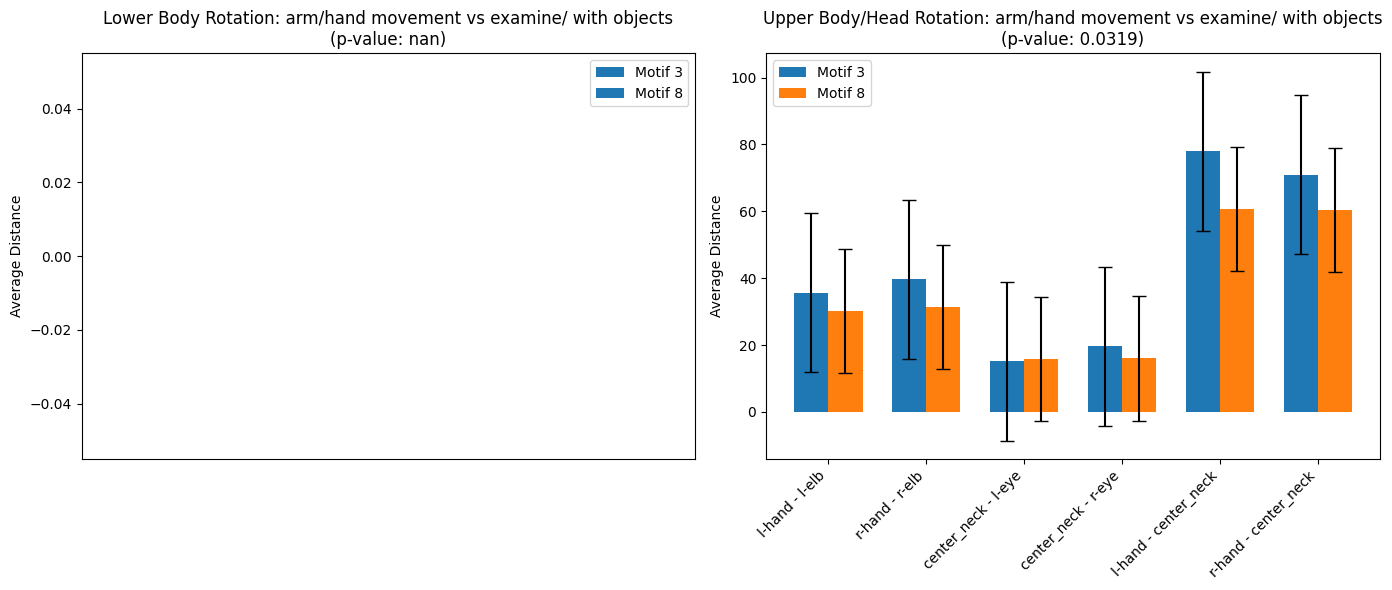

Lower Body Rotation p-value: nan
Upper Body/Head Rotation p-value: 0.0319


In [26]:
# Upper Body Pairs
upper_body_pairs = [
    "l-hand - l-elb",
    "r-hand - r-elb",
    "center_neck - l-eye",
    "center_neck - r-eye",
    "l-hand - center_neck",
    "r-hand - center_neck"
]

# Lower Body Pairs
lower_body_pairs = [
    
]

plot_motif_comparison(lower_body_pairs, upper_body_pairs, 3, 8)


# 5. Wander vs. Purposeful Approach
## Motif 6 (Wander and Scan Aimlessly) vs. Motif 9 (Approach with Aim and/or Inspect)
### Keypoint Pairs to Compare:

#### Lower Body Movement:
- center_hip - l-feet
- center_hip - r-feet
- l-feet - r-feet
#### Head/Gaze Focus:
- center_neck - l_eye
- center_neck - r_eye



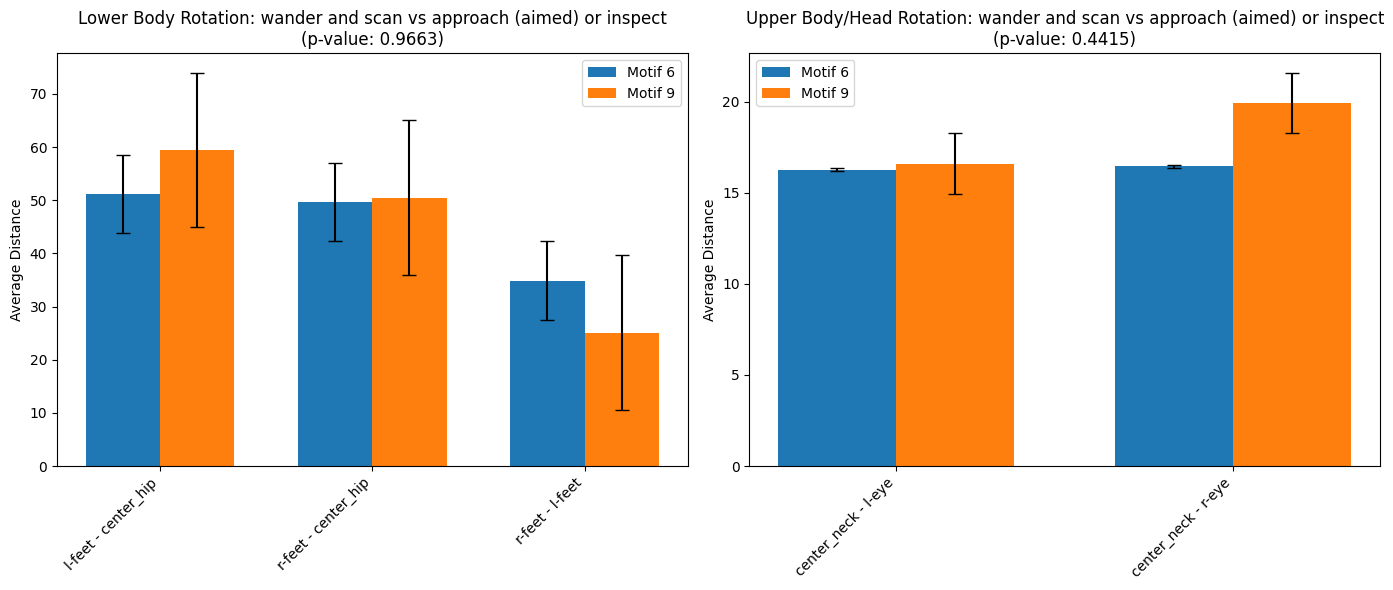

Lower Body Rotation p-value: 0.9663
Upper Body/Head Rotation p-value: 0.4415


In [27]:
# Lower Body Pairs
lower_body_pairs = [
    "l-feet - center_hip",
    "r-feet - center_hip",
    "r-feet - l-feet"
]

# Upper Body Pairs
upper_body_pairs = [
    "center_neck - l-eye",
    "center_neck - r-eye"
]

plot_motif_comparison(lower_body_pairs, upper_body_pairs, 6, 9)


# 6. Static (Fidget) vs. Standstill
## Motif 4 (Static or Fidget) vs. Motif 5 (Standstill)
### Keypoint Pairs to Compare:

#### Micro-movements:
- l-hand - l-elb
- r-hand - r-elb
#### Head/Eye Shifts:
- center_neck - l_eye
- center_neck - r_eye

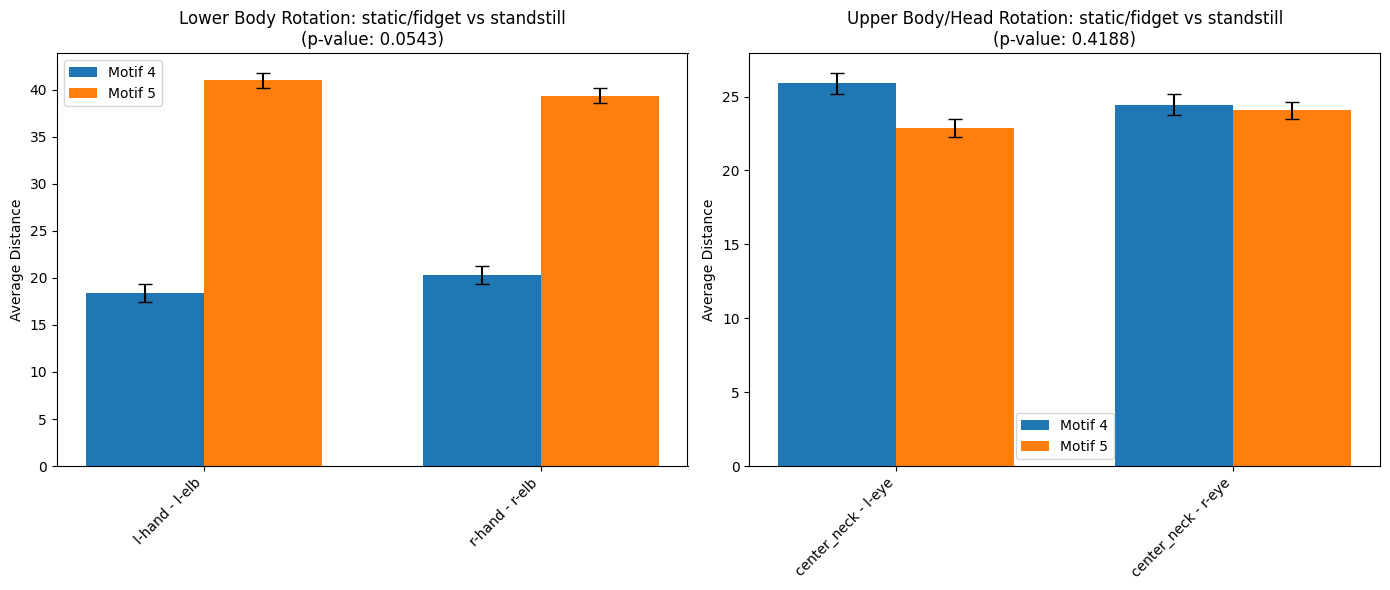

Lower Body Rotation p-value: 0.0543
Upper Body/Head Rotation p-value: 0.4188


In [28]:
# Lower Body Pairs (Micro-movements)
lower_body_pairs = [
    "l-hand - l-elb",
    "r-hand - r-elb"
]

# Upper Body Pairs (Head/Eye Shifts)
upper_body_pairs = [
    "center_neck - l-eye",
    "center_neck - r-eye"
]


plot_motif_comparison(lower_body_pairs, upper_body_pairs, 4, 5)

## For Motif 1 (Stretch One Body Part) vs Motif 9 (Approach with Aim and/or Inspect)
### Keypoints of Interest:

#### Lower Body Movement:
- l-hip - center_hip
- r-hip - center_hip
- l-feet - center_hip
- r-feet - center_hip
#### Upper Body/Head Coordination:
- center_neck - l_sho
- center_neck - r_sho
- center_neck - l_eye
- center_neck - r_eye
- l-hand - l-elb
- r-hand - r-elb

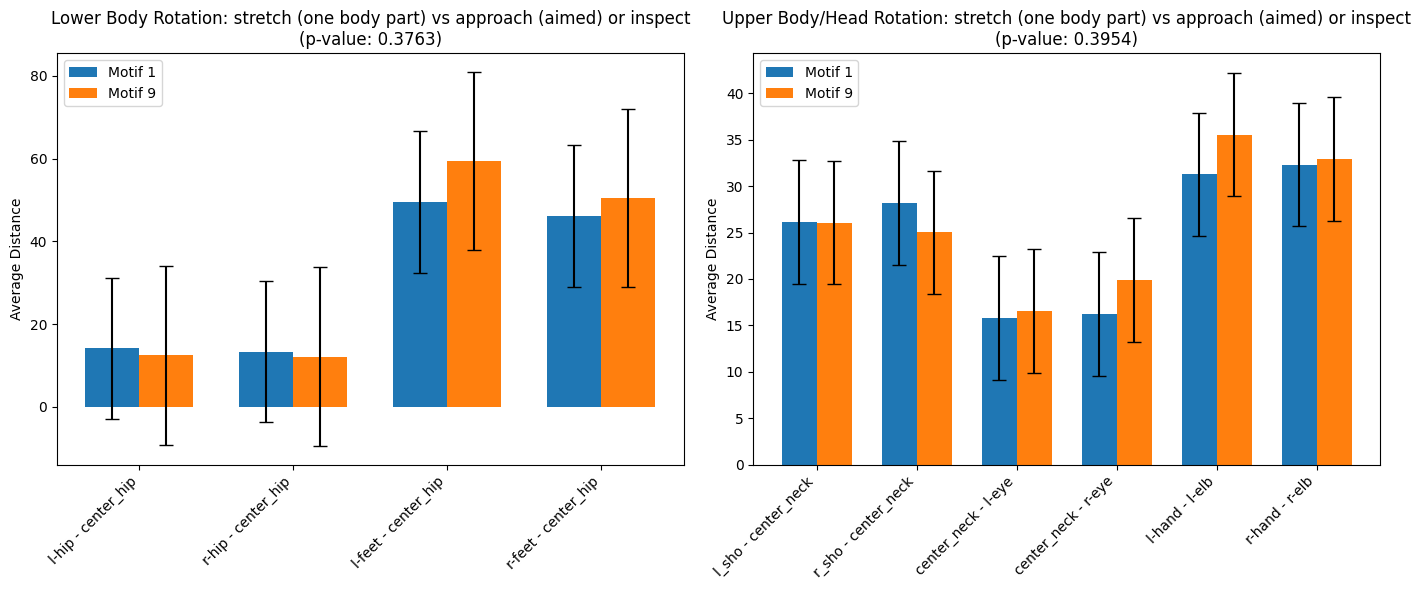

Lower Body Rotation p-value: 0.3763
Upper Body/Head Rotation p-value: 0.3954


In [29]:
# Motif 1 vs Motif 9
lower_body_pairs_1_9 = [
    "l-hip - center_hip",
    "r-hip - center_hip",
    "l-feet - center_hip",
    "r-feet - center_hip"
]

upper_body_pairs_1_9 = [
    "l_sho - center_neck",
    "r_sho - center_neck",
    "center_neck - l-eye",
    "center_neck - r-eye",
    "l-hand - l-elb",
    "r-hand - r-elb"
]

plot_motif_comparison(lower_body_pairs_1_9, upper_body_pairs_1_9, 1, 9)

## For Motif 4 (Static or Fidget) vs Motif 9 (Approach with Aim and/or Inspect)
### Keypoints of Interest:

#### Micro-Movements in Fidgeting vs Purposeful Motion:
- l-hand - l-elb
- r-hand - r-elb
- l-elb - l-sho
- r-elb - r-sho
#### Head/Gaze Focus for Inspection:
- center_neck - l_eye
- center_neck - r_eye
- center_hip - l-feet
- center_hip - r-feet

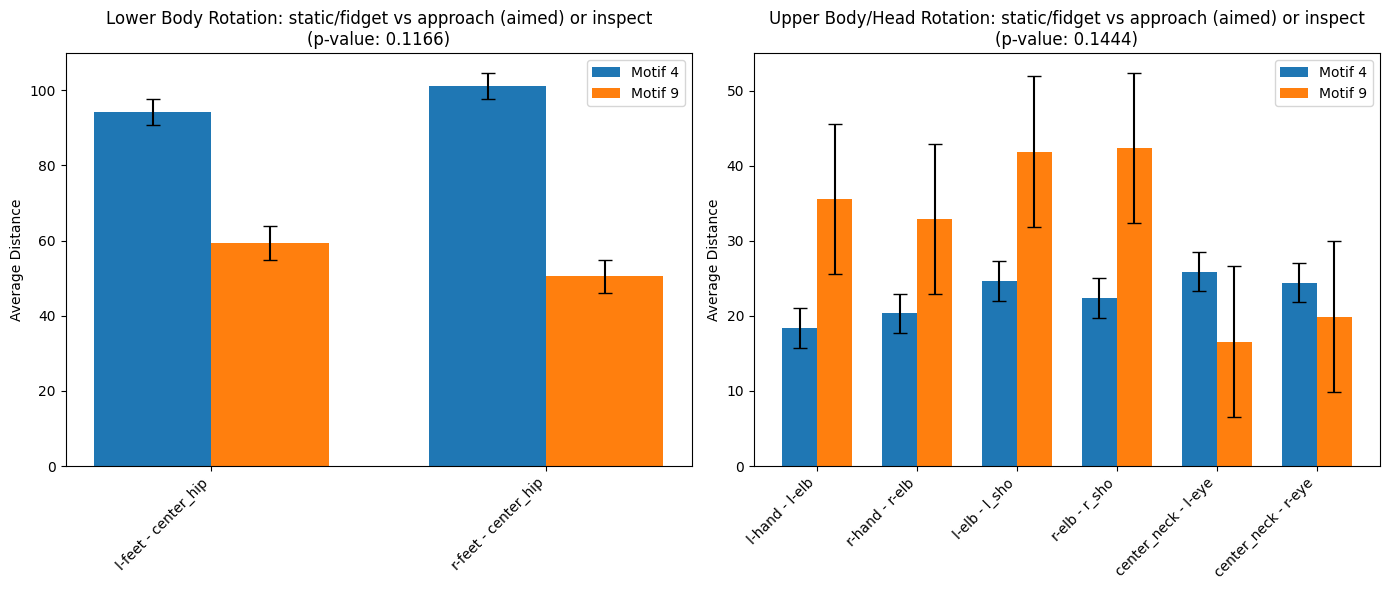

Lower Body Rotation p-value: 0.1166
Upper Body/Head Rotation p-value: 0.1444


In [30]:
# Motif 4 vs Motif 9
lower_body_pairs_4_9 = [
    "l-feet - center_hip",
    "r-feet - center_hip"
]

upper_body_pairs_4_9 = [
    "l-hand - l-elb",
    "r-hand - r-elb",
    "l-elb - l_sho",
    "r-elb - r_sho",
    "center_neck - l-eye",
    "center_neck - r-eye"
]

plot_motif_comparison(lower_body_pairs_4_9, upper_body_pairs_4_9, 4, 9)

# Motif 5 (Standstill) vs. Motif 6 (Wander and Scan Aimlessly)
Why Different:

Motif 5 has minimal to no movement across all keypoints.
Motif 6 involves continuous, aimless movement of both the lower body (feet, hips) and head/eyes for scanning.
## Keypoints to Compare:

### Lower Body Movement:
- l-feet - center_hip
- r-feet - center_hip
- l-hip - center_hip
- r-hip - center_hip
### Head/Eye Motion:
- center_neck - l_eye
- center_neck - r_eye

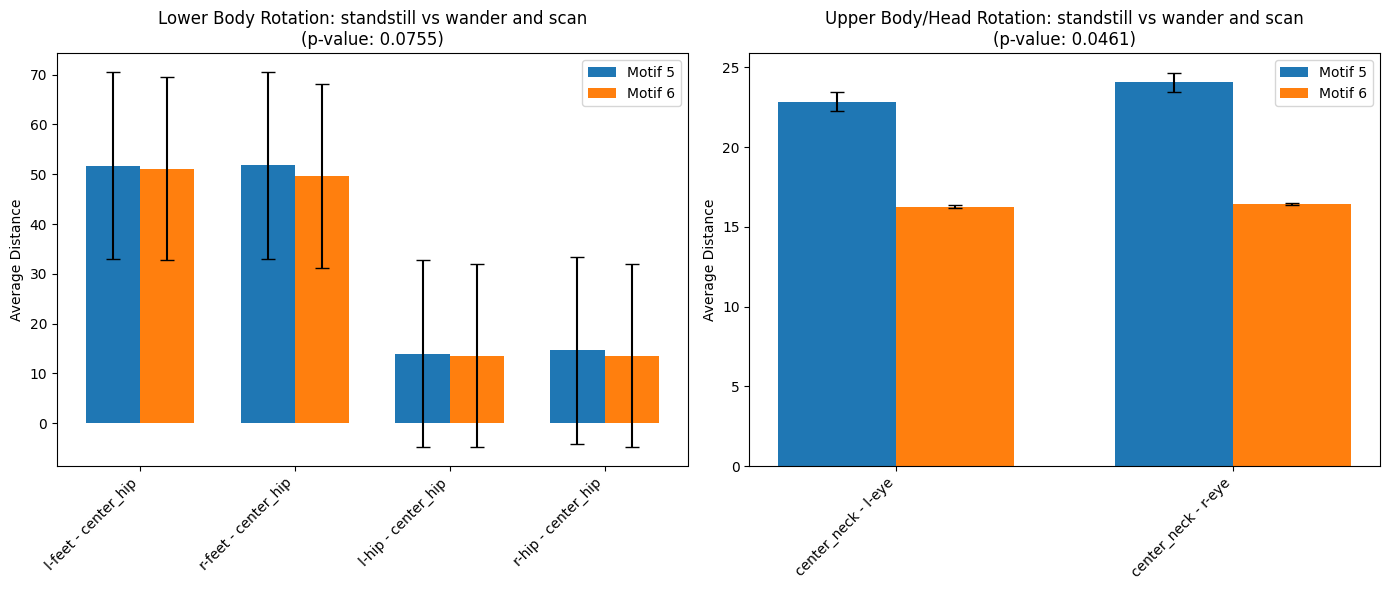

Lower Body Rotation p-value: 0.0755
Upper Body/Head Rotation p-value: 0.0461


In [31]:
# Motif 5 vs Motif 6
lower_body_pairs_5_6 = [
    "l-feet - center_hip",
    "r-feet - center_hip",
    "l-hip - center_hip",
    "r-hip - center_hip"
]

upper_body_pairs_5_6 = [
    "center_neck - l-eye",
    "center_neck - r-eye"
]

plot_motif_comparison(lower_body_pairs_5_6, upper_body_pairs_5_6, 5, 6)

# Motif 3 (Arm and Hand Movement) vs. Motif 9 (Approach with Aim and/or Inspect)
Why Different:

Motif 3 focuses mainly on upper body movements (arms, hands) with limited lower body movement.
Motif 9 requires full-body engagement, involving both purposeful stepping and focused head/eye movement.
## Keypoints to Compare:

### Lower Body (for approach):
- center_hip - l-feet
- center_hip - r-feet
### Upper Body (for reaching):
- l-hand - l-elb
- r-hand - r-elb
- center_neck - l_eye
- center_neck - r_eye

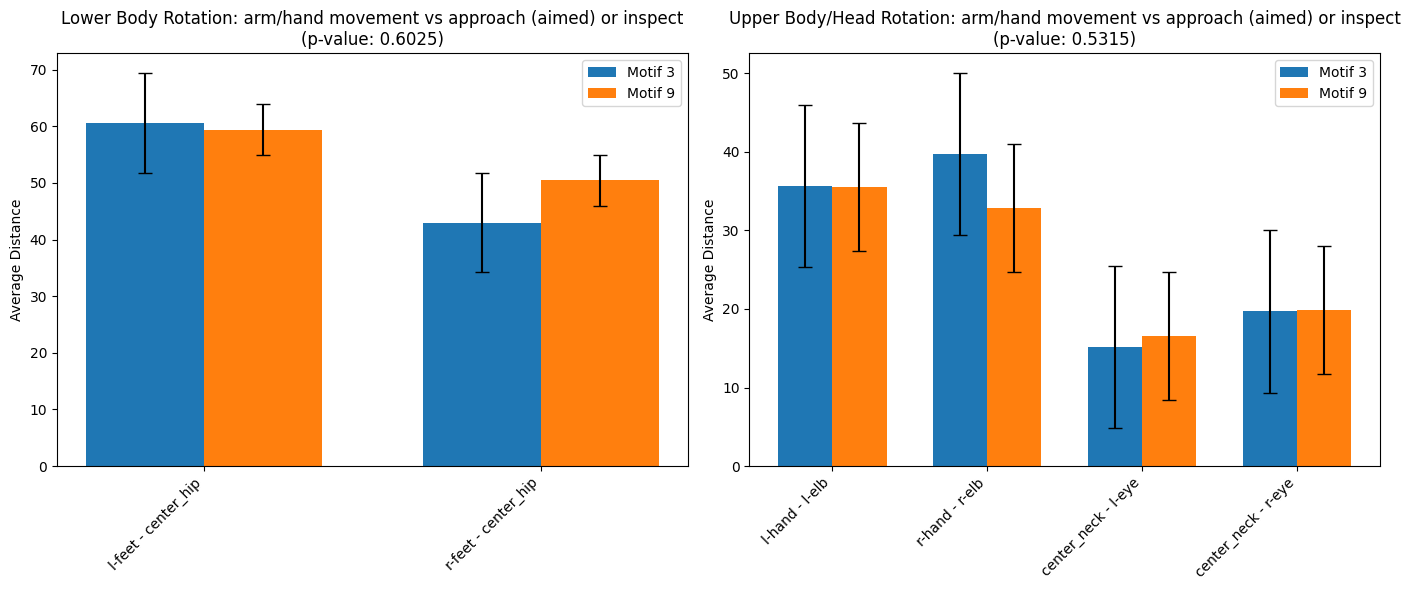

Lower Body Rotation p-value: 0.6025
Upper Body/Head Rotation p-value: 0.5315


In [32]:
# Motif 3 vs Motif 9
lower_body_pairs_3_9 = [
    "l-feet - center_hip",
    "r-feet - center_hip"
]

upper_body_pairs_3_9 = [
    "l-hand - l-elb",
    "r-hand - r-elb",
    "center_neck - l-eye",
    "center_neck - r-eye"
]

plot_motif_comparison(lower_body_pairs_3_9, upper_body_pairs_3_9, 3, 9)

# Motif 1 (Stretch One Body Part) vs. Motif 7 (Turn From/To)
Why Different:

Motif 1 involves slow, deliberate limb extension without much rotational motion.
Motif 7 requires sharp, rotational movements of both the upper body and lower body (especially hips and feet).
## Keypoints to Compare:

### Lower Body Rotation:
- center_hip - l-hip
- center_hip - r-hip
- l-hip - r-hip
### Upper Body Rotation vs. Stretch:
- center_neck - l_sho
- center_neck - r_sho

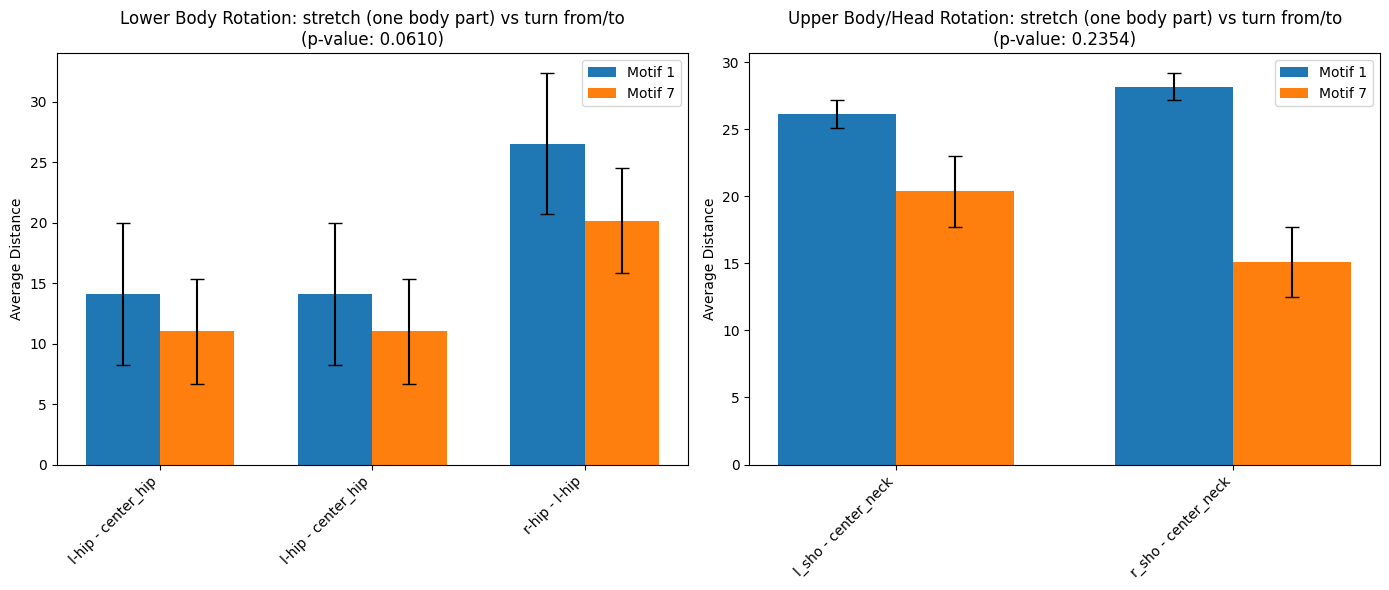

Lower Body Rotation p-value: 0.0610
Upper Body/Head Rotation p-value: 0.2354


In [33]:
# Motif 1 vs Motif 7
lower_body_pairs_1_7 = [
    "l-hip - center_hip",
    "l-hip - center_hip",
    "r-hip - l-hip"
]
upper_body_pairs_1_7 = [
    "l_sho - center_neck",
    "r_sho - center_neck"
]

plot_motif_comparison(lower_body_pairs_1_7, upper_body_pairs_1_7, 1, 7)

# Motif 4 (Static or Fidget) vs. Motif 6 (Wander and Scan Aimlessly)
Why Different:

Motif 4 involves tiny, localized micro-movements of hands/fingers.
Motif 6 involves broad, whole-body movement, especially legs/feet and head/eyes.
## Keypoints to Compare:

### Lower Body for Walking:
- l-feet - center_hip
- r-feet - center_hip
### Micro-Movements in Fidgeting:
- l-hand - l-elb
- r-hand - r-elb
- center_neck - l_eye
- center_neck - r_eye

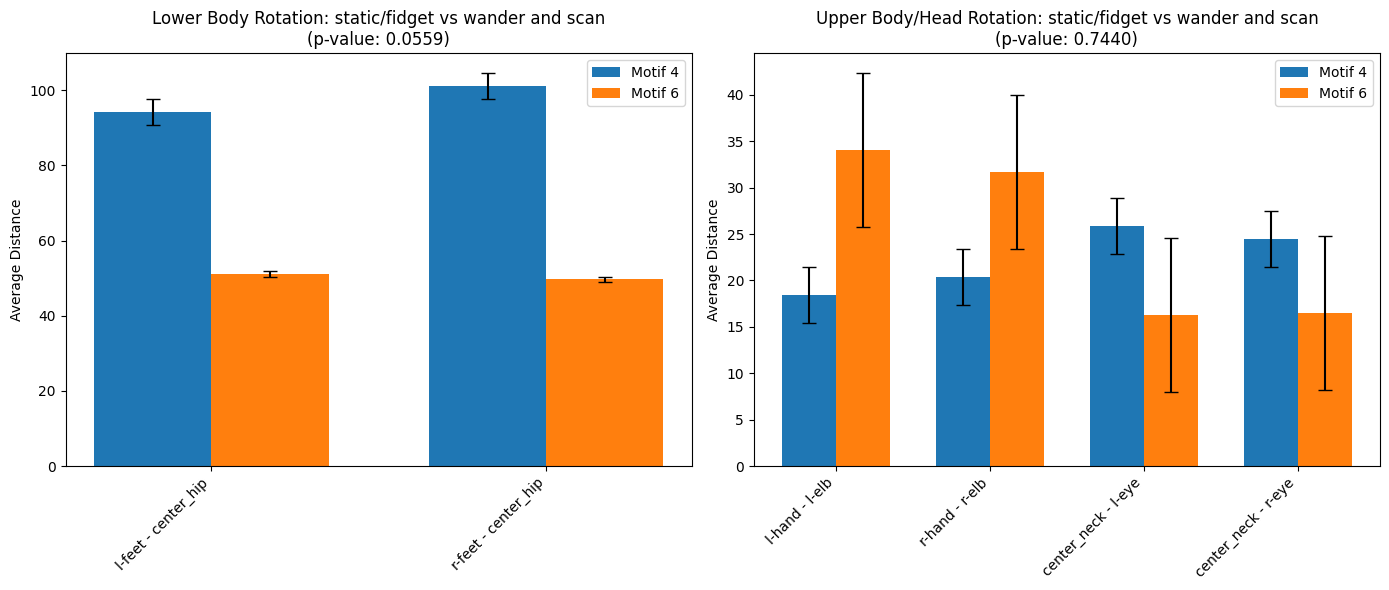

Lower Body Rotation p-value: 0.0559
Upper Body/Head Rotation p-value: 0.7440


In [34]:
# Motif 4 vs Motif 6
lower_body_pairs_4_6 = [
    "l-feet - center_hip",
    "r-feet - center_hip"
]

upper_body_pairs_4_6 = [
    "l-hand - l-elb",
    "r-hand - r-elb",
    "center_neck - l-eye",
    "center_neck - r-eye"
]

plot_motif_comparison(lower_body_pairs_4_6, upper_body_pairs_4_6, 4, 6)


# Motif 2 (Depart from Previous Action) vs. Motif 5 (Standstill)
Why this comparison?
Departing requires coordinated whole-body movement (especially in the lower body), while standstill should show minimal movement.

### Keypoints to Compare:

Lower Body: center_hip - l-feet, center_hip - r-feet, l-hip - r-hip
Upper Body: center_neck - l_sho, center_neck - r_sho
Head/Gaze: center_neck - l_eye, center_neck - r_eye

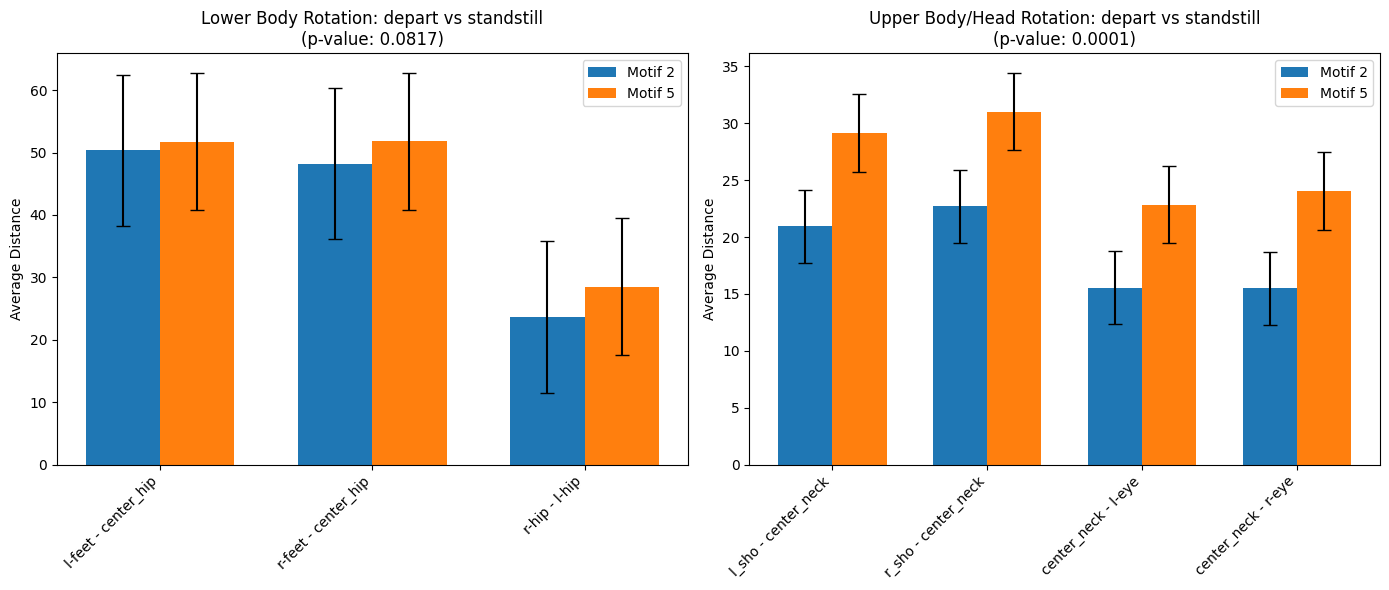

Lower Body Rotation p-value: 0.0817
Upper Body/Head Rotation p-value: 0.0001


In [35]:
lower_body_pairs = [
    "l-feet - center_hip",
    "r-feet - center_hip",
    "r-hip - l-hip"
]

# Upper Body Pairs
upper_body_pairs = [
    "l_sho - center_neck",
    "r_sho - center_neck",
    "center_neck - l-eye",
    "center_neck - r-eye"
]

plot_motif_comparison(lower_body_pairs, upper_body_pairs, 2, 5)

# Motif 0 (Torso Rotation) vs. Motif 3 (Arm and Hand Movement)
Why this comparison?
Torso rotation primarily engages the core and shoulders, while arm and hand movements focus on the upper limbs. These should show very different movement patterns.

## Keypoints to Compare:

Torso: center_hip - center_neck, center_neck - l_sho, center_neck - r_sho
Arms: l-hand - l-elb, r-hand - r-elb

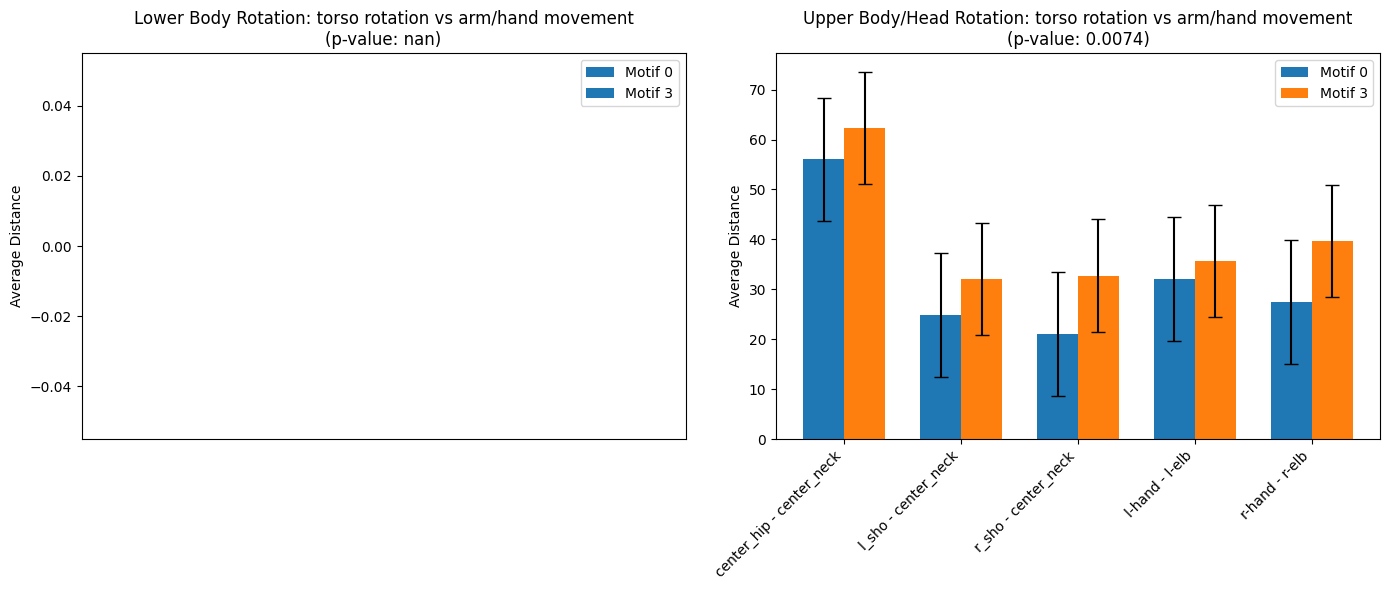

Lower Body Rotation p-value: nan
Upper Body/Head Rotation p-value: 0.0074


In [36]:
# Upper Body Keypoint Pairs
upper_body_pairs = [
    "center_hip - center_neck",
    "l_sho - center_neck",
    "r_sho - center_neck",
    "l-hand - l-elb",
    "r-hand - r-elb"
]

plot_motif_comparison([], upper_body_pairs, 0, 3)

# Motif 6 (Wander and Scan Aimlessly) vs. Motif 9 (Approach with Aim and/or Inspect)
Why this comparison?
Both involve movement, but wandering is more random, while approaching is purposeful and directed.

## Keypoints to Compare:

Lower Body: center_hip - l-feet, center_hip - r-feet, l-hip - r-hip
Head/Gaze: center_neck - l_eye, center_neck - r_eye

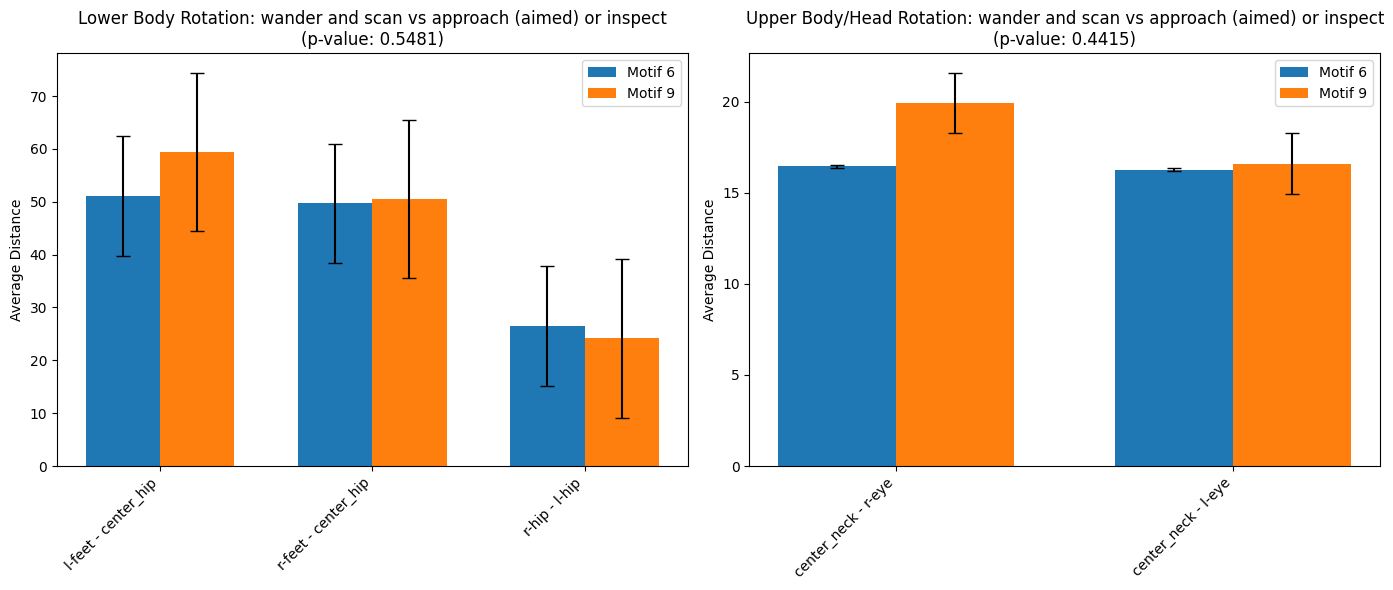

Lower Body Rotation p-value: 0.5481
Upper Body/Head Rotation p-value: 0.4415


In [37]:
# Lower Body Keypoint Pairs
lower_body_pairs = [
    "l-feet - center_hip",
    "r-feet - center_hip",
    "r-hip - l-hip"
]

# Head/Gaze Keypoint Pairs
head_gaze_pairs = [
    "center_neck - r-eye",
    "center_neck - l-eye",
]

plot_motif_comparison(lower_body_pairs, head_gaze_pairs, 6, 9)

# motif 1 (Stretch One Body Part) vs. Motif 8 (Examine/Interact with Objects)
Why this comparison?
Stretching involves large, slow, deliberate limb movements, while interacting involves precise hand movements with possible head/eye coordination.

## Keypoints to Compare:

Arms/Hands: l-hand - l-sho, r-hand - r-sho, l-hand - l-elb, r-hand - r-elb
Head/Gaze: center_neck - l_eye, center_neck - r_eye


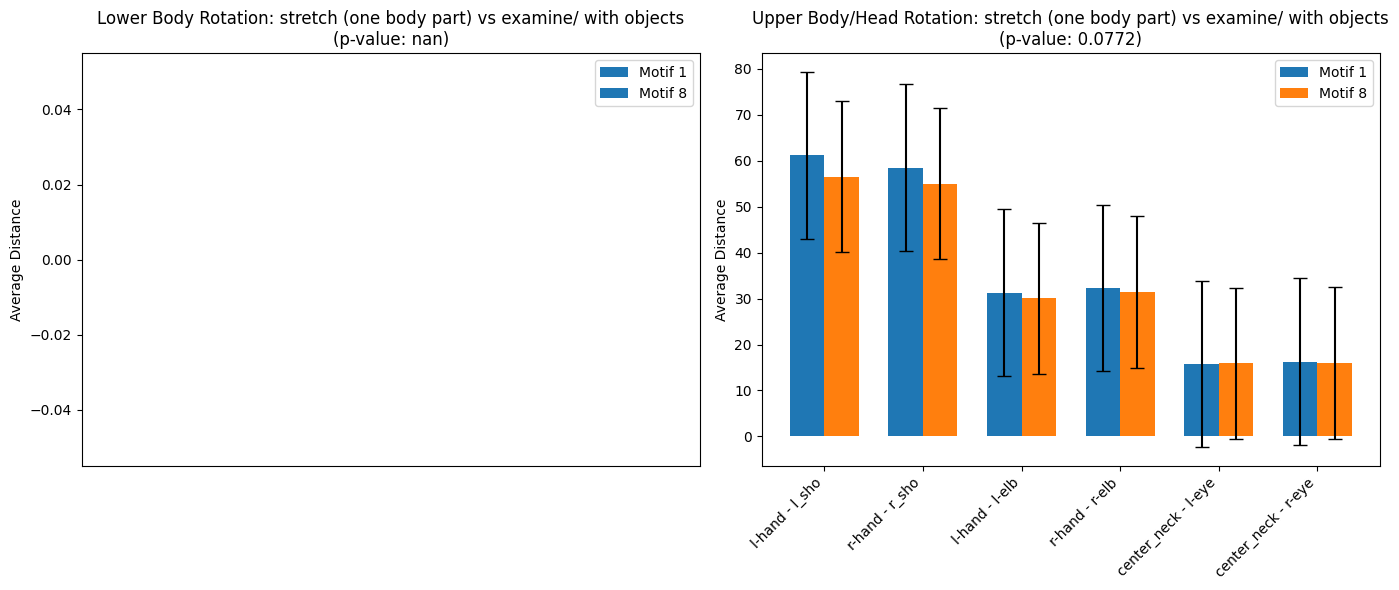

Lower Body Rotation p-value: nan
Upper Body/Head Rotation p-value: 0.0772


In [38]:
# Upper Body Keypoint Pairs (Arms/Hands and Head/Gaze)
upper_body_pairs = [
    "l-hand - l_sho",
    "r-hand - r_sho",
    "l-hand - l-elb",
    "r-hand - r-elb",
    "center_neck - l-eye",
    "center_neck - r-eye"
]

# Lower Body Keypoint Pairs (None specified for this case)
lower_body_pairs = []

plot_motif_comparison(lower_body_pairs, upper_body_pairs, 1, 8)

# Motif 4 (Static or Fidget) vs. Motif 6 (Wander and Scan Aimlessly)
Why this comparison?
Fidgeting is small, localized movement, while wandering involves whole-body, spatial movement.

## Keypoints to Compare:

Lower Body: center_hip - l-feet, center_hip - r-feet
Hands: l-hand - l-elb, r-hand - r-elb

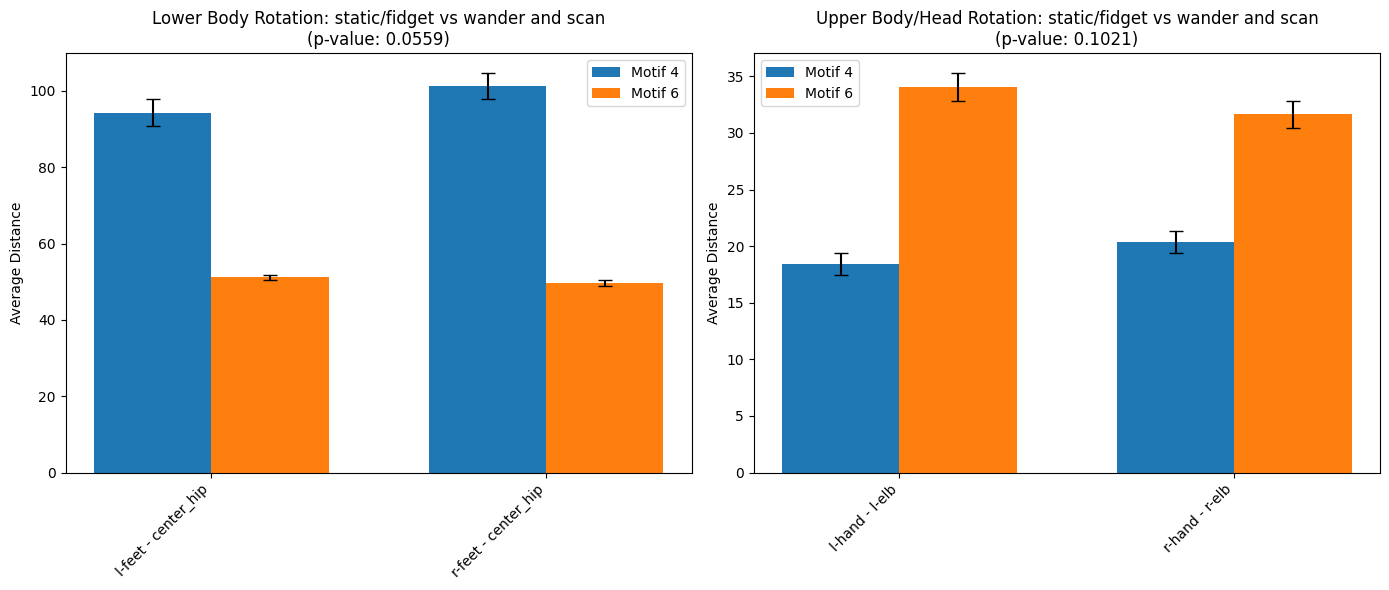

Lower Body Rotation p-value: 0.0559
Upper Body/Head Rotation p-value: 0.1021


In [39]:
# Upper Body Keypoint Pairs (Hands)
upper_body_pairs = [
    "l-hand - l-elb",
    "r-hand - r-elb"
]

# Lower Body Keypoint Pairs
lower_body_pairs = [
    "l-feet - center_hip",
    "r-feet - center_hip"
]

plot_motif_comparison(lower_body_pairs, upper_body_pairs, 4, 6)

# Motif 0 (Torso Rotation) vs. Motif 7 (Turn From/To)
Why this comparison?
Torso rotation is an isolated movement of the upper body, whereas turning involves coordinated whole-body rotation.

## Keypoints to Compare:

Lower Body: center_hip - l-hip, center_hip - r-hip
Upper Body: center_neck - l_sho, center_neck - r_sho
Head: center_neck - l_eye, center_neck - r_eye


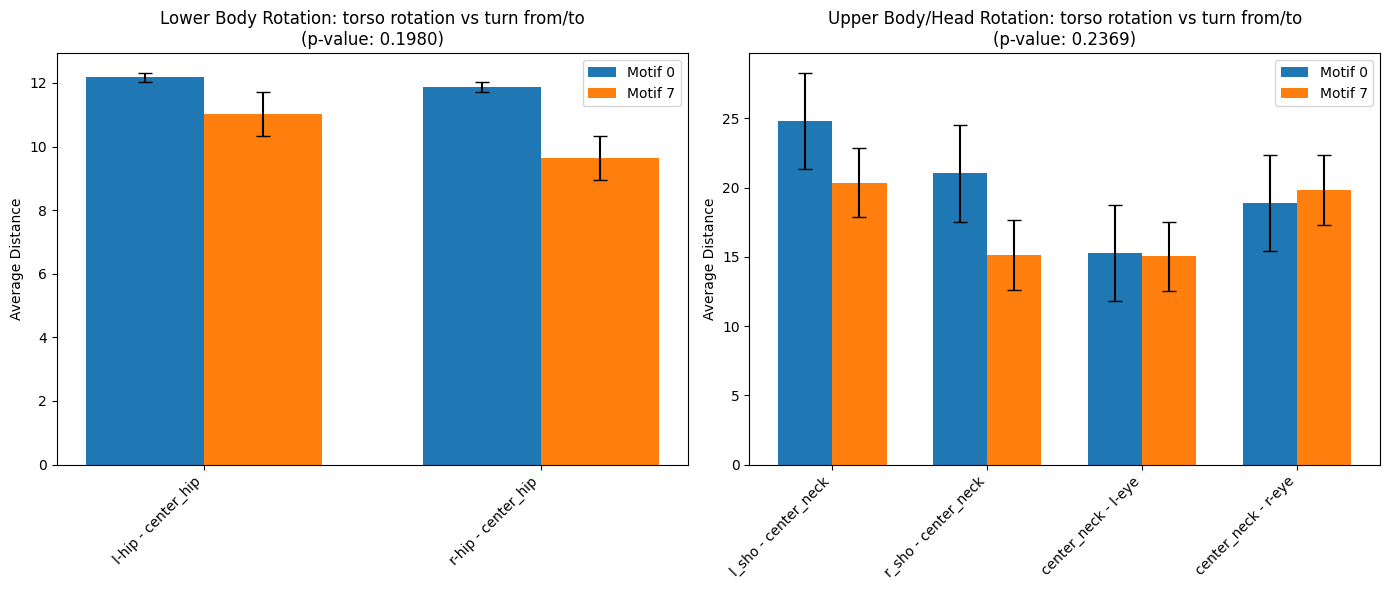

Lower Body Rotation p-value: 0.1980
Upper Body/Head Rotation p-value: 0.2369


In [40]:
# Lower Body Keypoint Pairs
lower_body_pairs = [
    "l-hip - center_hip",
    "r-hip - center_hip"
]

# Upper Body Keypoint Pairs
upper_body_pairs = [
    "l_sho - center_neck",
    "r_sho - center_neck",
    "center_neck - l-eye",
    "center_neck - r-eye"
]


plot_motif_comparison(lower_body_pairs, upper_body_pairs, 0, 7)

# Motif 3 (Arm and Hand Movement) vs. Motif 5 (Standstill)
Why this comparison?
Arm and hand movements involve dynamic upper limb activity, while standstill should show minimal to no movement.

## Keypoints to Compare:

Arms: l-hand - l-elb, r-hand - r-elb, l-elb - l-sho, r-elb - r-sho
Head/Gaze: center_neck - l_eye, center_neck - r_eye

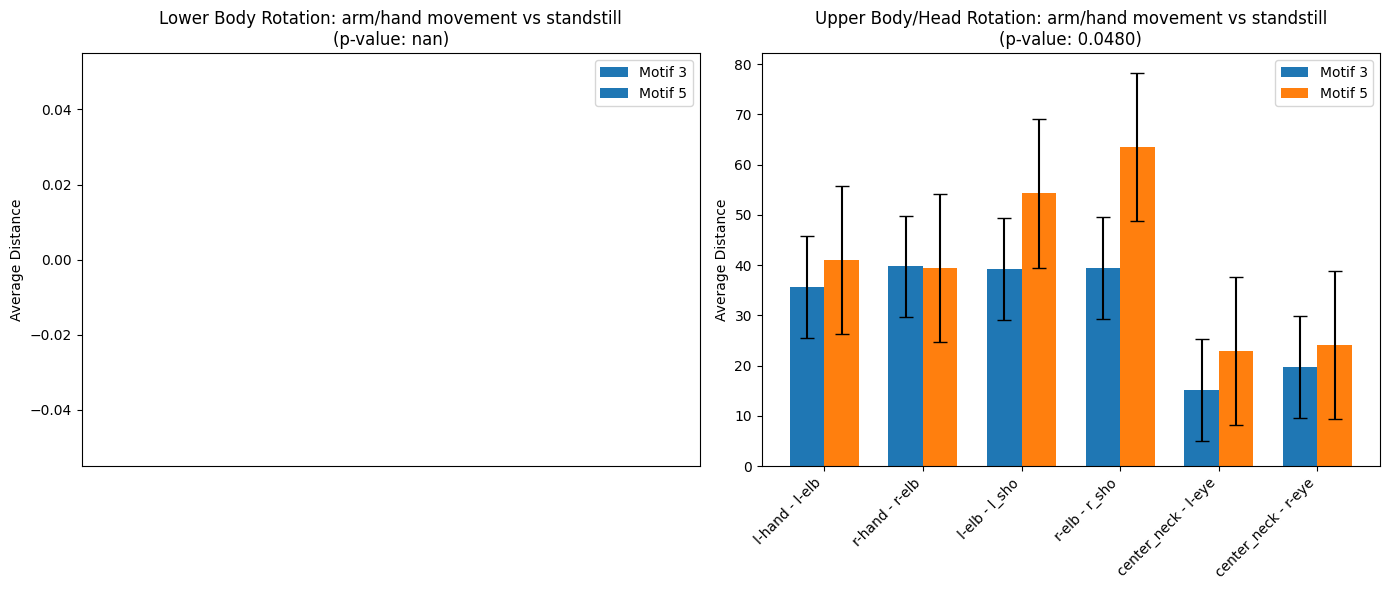

Lower Body Rotation p-value: nan
Upper Body/Head Rotation p-value: 0.0480


In [41]:
# Upper Body (Arms) Keypoint Pairs
upper_body_pairs = [
    "l-hand - l-elb",
    "r-hand - r-elb",
    "l-elb - l_sho",
    "r-elb - r_sho",
    "center_neck - l-eye",
    "center_neck - r-eye"
]

plot_motif_comparison([], upper_body_pairs, 3, 5)

# Motif 8 (Examine/Interact with Objects) vs. Motif 9 (Approach with Aim and/or Inspect)
Why this comparison?
Motif 8 focuses on precise hand-object interaction, while Motif 9 involves broader whole-body movement toward a target.

## Keypoints to Compare:

Lower Body: center_hip - l-feet, center_hip - r-feet
Hands/Arms: l-hand - l-elb, r-hand - r-elb
Head/Gaze: center_neck - l_eye, center_neck - r_eye

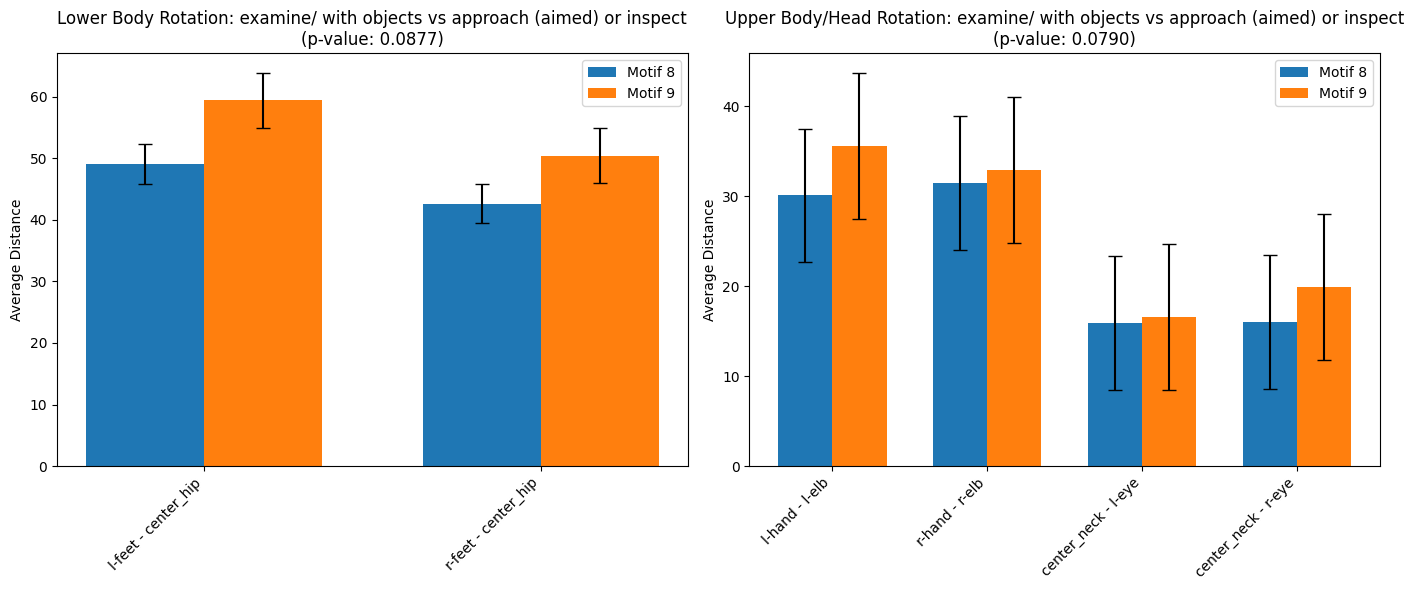

Lower Body Rotation p-value: 0.0877
Upper Body/Head Rotation p-value: 0.0790


In [42]:
# Lower Body Keypoint Pairs
lower_body_pairs = [
    "l-feet - center_hip",
    "r-feet - center_hip"
]

# Hands/Arms Keypoint Pairs
upper_body_pairs = [
    "l-hand - l-elb",
    "r-hand - r-elb",
    "center_neck - l-eye",
    "center_neck - r-eye"
]


plot_motif_comparison(lower_body_pairs, upper_body_pairs, 8, 9)